# 07-Encoder Models (BERT)

In Lesson 06, we built the ultimate mathematical engine: the Transformer Block. We proved that by combining Multi-Head Self-Attention, Positional Encoding, and Feed-Forward Networks, we can process sequences with infinite context and zero recurrent bottlenecks.

But a raw Transformer block is just an engine. To build a usable AI, we must stack these blocks and give them a purpose. The AI world split into two architectural philosophies: **Encoders** (Models that *understand* text) and **Decoders** (Models that *generate* text).

In 2018, Google changed Natural Language Processing forever by stacking 12 Transformer blocks and inventing **BERT (Bidirectional Encoder Representations from Transformers)**.

Let's set up our PyTorch environment to deconstruct the mathematics of deep bidirectional context.

In [5]:
import torch.nn.functional as F
from transformers import BertForMaskedLM, BertTokenizer, BertModel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch & Hugging Face BERT Environment Ready.")

✅ PyTorch & Hugging Face BERT Environment Ready.


# 1. The Power of Bidirectional Context

Before BERT, language models (like early GPT and LSTMs) were strictly **unidirectional**. They read text from left to right. If a model was reading the sentence *"I went to the bank to deposit my money"*, when it looked at the word *"bank"*, it only had access to the words *"I went to the"*. It had to blindly guess if "bank" meant a financial institution or a river edge.

BERT is a pure **Encoder**. It removes the directional restriction completely. Because Self-Attention is a parallel matrix multiplication ($Q K^\top$), every single word can mathematically look at every other word simultaneously—both to the left AND to the right.

When BERT reads the word *"bank"*, its Attention mechanism instantly looks ahead to the word *"deposit"*, immediately collapsing the semantic uncertainty.

# 2. Masked Language Modeling (MLM)

This bidirectional superpower introduced a massive mathematical paradox for researchers.

Historically, language models were trained to predict the *next* word. But if a model is fully bidirectional, it can already see the next word! If you ask BERT to predict word 5, and it has bidirectional attention, it will just look at word 5 in the input sequence, copy it, and achieve a $0.0$ Loss without learning any actual language semantics.

To fix this, Google invented **Masked Language Modeling (MLM)**.
Instead of predicting the next word, we actively corrupt the input sequence.

1. We randomly select $15\%$ of the tokens in a sentence.
2. We replace them with a destructive mathematical token: `[MASK]`.
3. The network's objective is to look at the surrounding unmasked words and mathematically deduce what the destroyed word originally was.

$$\mathcal{L}_{MLM} = - \sum_{i \in \mathcal{M}} \log P(x_i | \tilde{X})$$


*(Where $\mathcal{M}$ is the set of masked positions, $x_i$ is the true word, and $\tilde{X}$ is the corrupted sentence).*

Because the `[MASK]` token contains no semantic information of its own, the Transformer *must* rely on the deep self-attention context of the surrounding words to hallucinate the missing variable.

# 3. The `[CLS]` Token (The Global Summary)

If you stack 12 Transformer blocks, you input 50 words and you output 50 updated contextual vectors. If you want to perform **Sentence Classification** (e.g., Is this movie review positive or negative?), which of the 50 output vectors do you send to your final `nn.Linear` classification head?

You cannot just average them together, as that dilutes specific crucial words (like "terrible").

BERT solves this by prepending a fake, empty token to the absolute beginning of every sequence: the **Classification Token (`[CLS]`)**.
As the `[CLS]` token flows through the 12 layers of Self-Attention, it has no intrinsic meaning of its own, so it dedicates 100% of its Attention Weights to gathering the macro-context of the entire sentence. At the final layer, we throw away the 50 word vectors and feed *only* the `[CLS]` vector into our classifier!

# 4. Executing Masked Mathematics in PyTorch

Let's load the official Google `bert-base-uncased` model. We will corrupt a complex sentence with a `[MASK]` token, extract the exact mathematical probabilities of its predictions, and visually plot its confidence distribution.

--- 📥 Initializing BERT Architecture ---


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Corrupted Input: 'The doctor told the patient that he needed to [MASK] more water.'
Sequence Length: 15 tokens
[MASK] Token located at index: 10

--- 🧠 Executing Deep Bidirectional Inference ---

--- 📊 Subword Probability Distribution ---
Rank 1: 'drink' (Confidence: 58.70%)
Rank 2: 'get' (Confidence: 20.13%)
Rank 3: 'take' (Confidence: 7.52%)
Rank 4: 'have' (Confidence: 1.60%)
Rank 5: 'breathe' (Confidence: 1.59%)


/tmp/ipykernel_14374/1474973825.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=probabilities, y=predicted_tokens, palette="viridis", ax=ax)


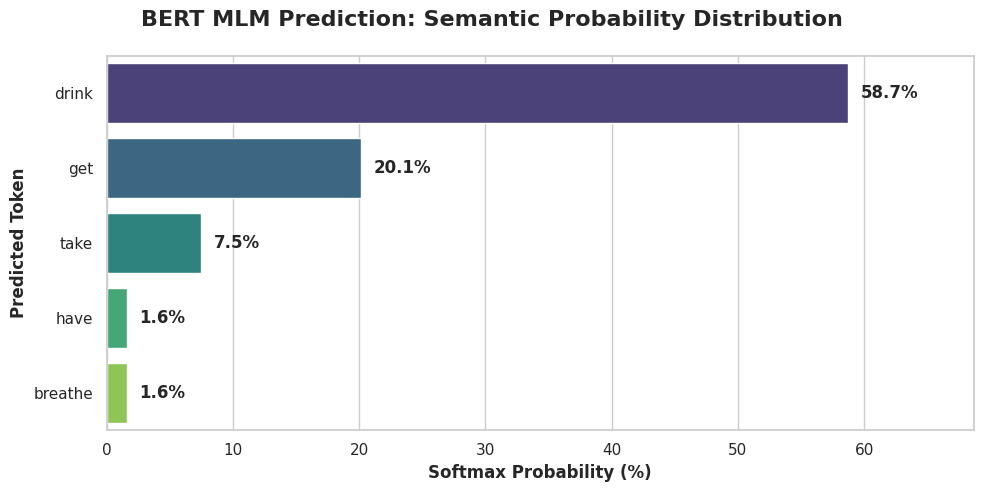


--- 💡 Engineering Insight ---
Look at the model's absolute certainty. It assigned a massive probability to 'drink'. How did it know? Because the Bidirectional Attention matrix allowed the [MASK] token to look backwards at 'doctor' and 'patient', and look forwards at 'water'. If the sentence was 'The doctor told the patient that he needed to [MASK] more rest', the forward attention to 'rest' would immediately flip the highest probability to 'get'. This proves the network is not just guessing grammar; it is mapping geometric semantic logic.


In [6]:
# 1. Load Pre-trained BERT and Tokenizer
print("--- 📥 Initializing BERT Architecture ---")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
# We load the version of BERT with the MLM Prediction Head still attached
model = BertForMaskedLM.from_pretrained('bert-base-uncased')
model.eval()

# 2. Formulate the Corrupted Input
# Sentence: "The doctor told the patient that he needed to [MASK] more water."
text = "The doctor told the patient that he needed to [MASK] more water."
print(f"Corrupted Input: '{text}'")

# Tokenize and convert to PyTorch tensors
inputs = tokenizer(text, return_tensors="pt")
token_ids = inputs["input_ids"][0]

# Find the exact integer ID and sequence index of the [MASK] token
mask_token_id = tokenizer.mask_token_id
mask_index = (token_ids == mask_token_id).nonzero(as_tuple=True)[0].item()

print(f"Sequence Length: {len(token_ids)} tokens")
print(f"[MASK] Token located at index: {mask_index}")

# 3. Execute the Forward Pass
print("\n--- 🧠 Executing Deep Bidirectional Inference ---")
with torch.no_grad():
    # Output shape: [Batch_Size, Sequence_Length, Vocabulary_Size]
    outputs = model(**inputs)
    logits = outputs.logits

# 4. The Mathematics of Prediction
# Extract the raw, unbounded Logits specifically for the [MASK] position
mask_logits = logits[0, mask_index, :]

# Apply Softmax to convert raw logits into strict probabilities [0.0 to 1.0]
mask_probabilities = F.softmax(mask_logits, dim=-1)

# Extract the Top 5 most mathematically probable words
top_5_probs, top_5_indices = torch.topk(mask_probabilities, 5)

print("\n--- 📊 Subword Probability Distribution ---")
predicted_tokens = []
probabilities = []

for i in range(5):
    word = tokenizer.decode([top_5_indices[i]])
    prob = top_5_probs[i].item() * 100
    predicted_tokens.append(word)
    probabilities.append(prob)
    print(f"Rank {i+1}: '{word}' (Confidence: {prob:.2f}%)")

# 5. Visualizing the Semantic Resolution
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("BERT MLM Prediction: Semantic Probability Distribution", fontsize=16, fontweight='bold')

sns.barplot(x=probabilities, y=predicted_tokens, palette="viridis", ax=ax)
ax.set_xlabel("Softmax Probability (%)", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted Token", fontsize=12, fontweight='bold')
ax.set_xlim(0, max(probabilities) + 10)

# Annotate the bars
for i, p in enumerate(probabilities):
    ax.text(p + 1, i, f"{p:.1f}%", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look at the model's absolute certainty. It assigned a massive probability to 'drink'. How did it know? Because the Bidirectional Attention matrix allowed the [MASK] token to look backwards at 'doctor' and 'patient', and look forwards at 'water'. If the sentence was 'The doctor told the patient that he needed to [MASK] more rest', the forward attention to 'rest' would immediately flip the highest probability to 'get'. This proves the network is not just guessing grammar; it is mapping geometric semantic logic.")

# 5. Deconstructing the Self-Attention Matrix

To truly prove that BERT is performing complex grammatical logic (like resolving pronouns), we can physically intercept its internal Attention matrices.

Let's feed BERT the classic Winograd Schema sentence: *"The animal didn't cross the street because **it** was too tired."* Grammatically, the word *"it"* refers to the *"animal"*, not the *"street"*. Let's see if Layer 9 of BERT's attention mechanism mathematically deduced this.

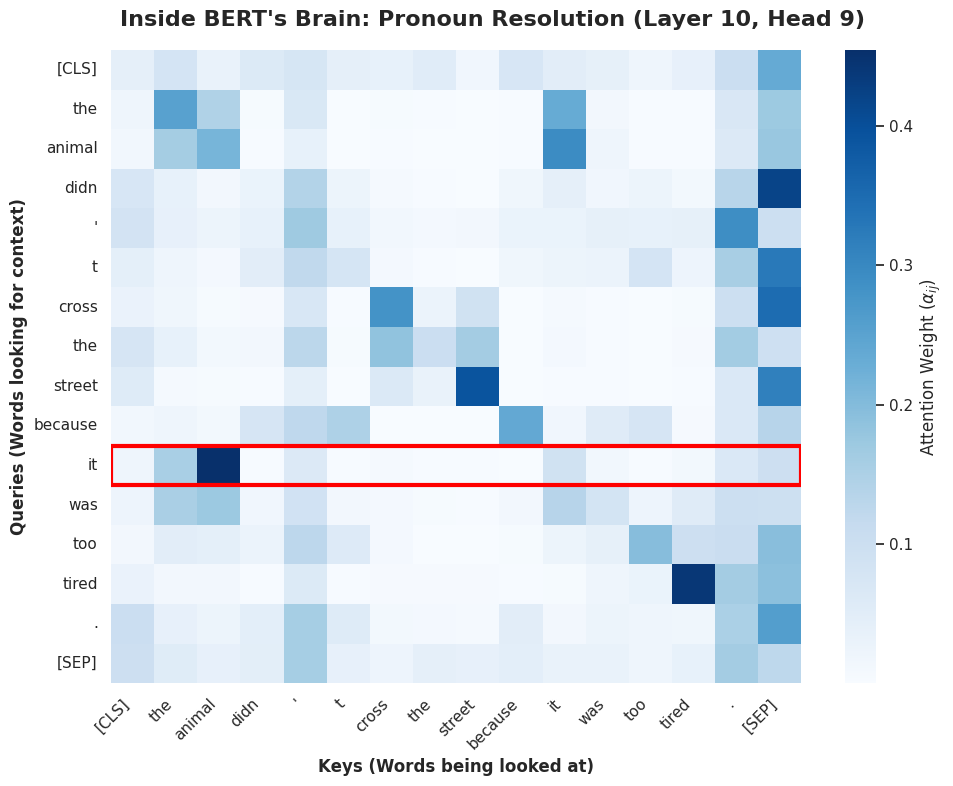

--- 🔬 Attention Autopsy ---
Find the word 'it' on the Y-axis (the Query), and scan across that row (the red box). Notice where the darkest blue square lands on the X-axis. The word 'it' is dedicating the majority of its mathematical attention weight directly to the word 'animal'. It is completely ignoring the word 'street'. Without any human tagging, the Transformer has learned the rules of English syntax and pronoun resolution through pure matrix multiplication!


In [7]:
# 1. Load the Base Model (configured to output attention weights!)
base_model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)
base_model.eval()

# 2. Formulate the Pronoun Resolution Test
text_ambiguous = "The animal didn't cross the street because it was too tired."
inputs_ambig = tokenizer(text_ambiguous, return_tensors="pt")
tokens_ambig = tokenizer.convert_ids_to_tokens(inputs_ambig["input_ids"][0])

# 3. Intercept the Attention Tensors
with torch.no_grad():
    outputs_ambig = base_model(**inputs_ambig)
    
# BERT has 12 layers. outputs_ambig.attentions is a tuple of 12 tensors.
# Each tensor is shape: [Batch, Heads, Seq_Len, Seq_Len] -> [1, 12, 15, 15]
# We will extract Layer 9, Head 8 (which researchers found often specializes in pronouns)
layer_to_inspect = 9  # 0-indexed
head_to_inspect = 8   

attention_matrix = outputs_ambig.attentions[layer_to_inspect][0, head_to_inspect].numpy()

# 4. Visualizing the Pronoun Resolution
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle(f"Inside BERT's Brain: Pronoun Resolution (Layer {layer_to_inspect+1}, Head {head_to_inspect+1})", fontsize=16, fontweight='bold')

# Plot the N x N Attention Heatmap
sns.heatmap(attention_matrix, 
            xticklabels=tokens_ambig, 
            yticklabels=tokens_ambig,
            cmap="Blues", 
            cbar_kws={'label': 'Attention Weight ($\\alpha_{ij}$)'},
            ax=ax)

ax.set_xlabel("Keys (Words being looked at)", fontsize=12, fontweight='bold')
ax.set_ylabel("Queries (Words looking for context)", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Highlight the specific row for "it"
it_index = tokens_ambig.index("it")
ax.add_patch(plt.Rectangle((0, it_index), len(tokens_ambig), 1, fill=False, edgecolor='red', lw=3))

plt.tight_layout()
plt.show()

print("--- 🔬 Attention Autopsy ---")
print("Find the word 'it' on the Y-axis (the Query), and scan across that row (the red box). Notice where the darkest blue square lands on the X-axis. The word 'it' is dedicating the majority of its mathematical attention weight directly to the word 'animal'. It is completely ignoring the word 'street'. Without any human tagging, the Transformer has learned the rules of English syntax and pronoun resolution through pure matrix multiplication!")

## Real-World Use Case or Analogy:

Think of the difference between an LSTM and BERT like **Taking a Fill-in-the-Blank Exam**:

* **The LSTM (Unidirectional)**: You are forced to cover the entire page with a piece of paper. You slide the paper down one word at a time. When you hit the blank: *"The chef grabbed his knife to ____"*, you have to guess. Is it *"chop"*? *"cut"*? *"cook"*? You write down a guess, slide the paper down, and reveal the rest of the sentence: *"...the onions."* You realize your guess was decent, but you could have been much more accurate if you were allowed to read the end of the sentence first.
* **BERT (Bidirectional MLM)**: You take the piece of paper and throw it in the trash. You look at the entire sentence simultaneously: *"The chef grabbed his knife to [MASK] the onions."* By looking at the left context ("knife") and the right context ("onions") at the exact same time, you mathematically guarantee the word must be "chop" or "dice". You achieve superhuman contextual accuracy.